In [31]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier

from imblearn.over_sampling import SMOTE

from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    roc_auc_score
)

import warnings
warnings.filterwarnings("ignore")

In [92]:
import os

os.makedirs("../reports", exist_ok=True)

In [34]:
df = pd.read_csv("/Users/jasleenkaur/Credit-Risk-Scoring-Model/data/raw/UCI_Credit_Card.csv")

In [45]:
df = df.rename(
    columns={
        "default.payment.next.month": "default"
    }
)
print("Target column renamed successfully.")

Target column renamed successfully.


In [46]:
print("Dataset Shape:", df.shape)

Dataset Shape: (30000, 25)


In [47]:
df.head()

,ID,LIMIT_BAL,SEX,EDUCATION,MARRIAGE,AGE,PAY_0,PAY_2,PAY_3,PAY_4,...,BILL_AMT4,BILL_AMT5,BILL_AMT6,PAY_AMT1,PAY_AMT2,PAY_AMT3,PAY_AMT4,PAY_AMT5,PAY_AMT6,default
0,1,20000.0,2,2,1,24,2,2,-1,-1,...,0.0,0.0,0.0,0.0,689.0,0.0,0.0,0.0,0.0,1
1,2,120000.0,2,2,2,26,-1,2,0,0,...,3272.0,3455.0,3261.0,0.0,1000.0,1000.0,1000.0,0.0,2000.0,1
2,3,90000.0,2,2,2,34,0,0,0,0,...,14331.0,14948.0,15549.0,1518.0,1500.0,1000.0,1000.0,1000.0,5000.0,0
3,4,50000.0,2,2,1,37,0,0,0,0,...,28314.0,28959.0,29547.0,2000.0,2019.0,1200.0,1100.0,1069.0,1000.0,0
4,5,50000.0,1,2,1,57,-1,0,-1,0,...,20940.0,19146.0,19131.0,2000.0,36681.0,10000.0,9000.0,689.0,679.0,0


In [48]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 30000 entries, 0 to 29999
Data columns (total 25 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   ID         30000 non-null  int64  
 1   LIMIT_BAL  30000 non-null  float64
 2   SEX        30000 non-null  int64  
 3   EDUCATION  30000 non-null  int64  
 4   MARRIAGE   30000 non-null  int64  
 5   AGE        30000 non-null  int64  
 6   PAY_0      30000 non-null  int64  
 7   PAY_2      30000 non-null  int64  
 8   PAY_3      30000 non-null  int64  
 9   PAY_4      30000 non-null  int64  
 10  PAY_5      30000 non-null  int64  
 11  PAY_6      30000 non-null  int64  
 12  BILL_AMT1  30000 non-null  float64
 13  BILL_AMT2  30000 non-null  float64
 14  BILL_AMT3  30000 non-null  float64
 15  BILL_AMT4  30000 non-null  float64
 16  BILL_AMT5  30000 non-null  float64
 17  BILL_AMT6  30000 non-null  float64
 18  PAY_AMT1   30000 non-null  float64
 19  PAY_AMT2   30000 non-null  float64
 20  PAY_AMT3   30000 

In [49]:
df.isnull().sum()

ID           0
LIMIT_BAL    0
SEX          0
EDUCATION    0
MARRIAGE     0
AGE          0
PAY_0        0
PAY_2        0
PAY_3        0
PAY_4        0
PAY_5        0
PAY_6        0
BILL_AMT1    0
BILL_AMT2    0
BILL_AMT3    0
BILL_AMT4    0
BILL_AMT5    0
BILL_AMT6    0
PAY_AMT1     0
PAY_AMT2     0
PAY_AMT3     0
PAY_AMT4     0
PAY_AMT5     0
PAY_AMT6     0
default      0
dtype: int64

In [50]:
df.describe()

,ID,LIMIT_BAL,SEX,EDUCATION,MARRIAGE,AGE,PAY_0,PAY_2,PAY_3,PAY_4,...,BILL_AMT4,BILL_AMT5,BILL_AMT6,PAY_AMT1,PAY_AMT2,PAY_AMT3,PAY_AMT4,PAY_AMT5,PAY_AMT6,default
count,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000,...,30000.000000,30000.000000,30000.000000,30000.000000,3.000000e+04,30000.00000,30000.000000,30000.000000,30000.000000,30000.000000
mean,15000.500000,167484.322667,1.603733,1.853133,1.551867,35.485500,-0.016700,-0.133767,-0.166200,-0.220667,...,43262.948967,40311.400967,38871.760400,5663.580500,5.921163e+03,5225.68150,4826.076867,4799.387633,5215.502567,0.221200
std,8660.398374,129747.661567,0.489129,0.790349,0.521970,9.217904,1.123802,1.197186,1.196868,1.169139,...,64332.856134,60797.155770,59554.107537,16563.280354,2.304087e+04,17606.96147,15666.159744,15278.305679,17777.465775,0.415062
min,1.000000,10000.000000,1.000000,0.000000,0.000000,21.000000,-2.000000,-2.000000,-2.000000,-2.000000,...,-170000.000000,-81334.000000,-339603.000000,0.000000,0.000000e+00,0.00000,0.000000,0.000000,0.000000,0.000000
25%,7500.750000,50000.000000,1.000000,1.000000,1.000000,28.000000,-1.000000,-1.000000,-1.000000,-1.000000,...,2326.750000,1763.000000,1256.000000,1000.000000,8.330000e+02,390.00000,296.000000,252.500000,117.750000,0.000000
50%,15000.500000,140000.000000,2.000000,2.000000,2.000000,34.000000,0.000000,0.000000,0.000000,0.000000,...,19052.000000,18104.500000,17071.000000,2100.000000,2.009000e+03,1800.00000,1500.000000,1500.000000,1500.000000,0.000000
75%,22500.250000,240000.000000,2.000000,2.000000,2.000000,41.000000,0.000000,0.000000,0.000000,0.000000,...,54506.000000,50190.500000,49198.250000,5006.000000,5.000000e+03,4505.00000,4013.250000,4031.500000,4000.000000,0.000000
max,30000.000000,1000000.000000,2.000000,6.000000,3.000000,79.000000,8.000000,8.000000,8.000000,8.000000,...,891586.000000,927171.000000,961664.000000,873552.000000,1.684259e+06,896040.00000,621000.000000,426529.000000,528666.000000,1.000000


In [54]:
target_counts = df['default'].value_counts()
print(target_counts)
print(
    df['default']
    .value_counts(normalize=True) * 100
)

default
0    23364
1     6636
Name: count, dtype: int64
default
0    77.88
1    22.12
Name: proportion, dtype: float64


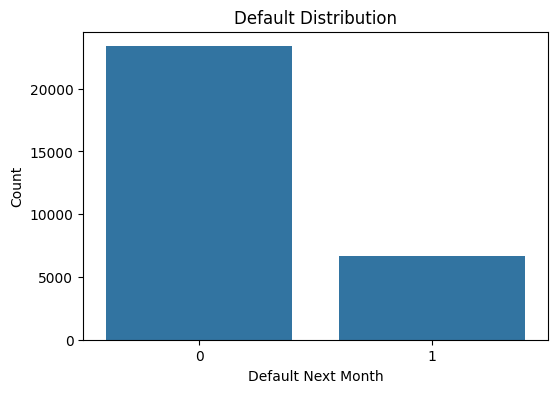

In [55]:
plt.figure(figsize=(6,4))

sns.countplot(
    x='default',
    data=df
)

plt.title("Default Distribution")
plt.xlabel("Default Next Month")
plt.ylabel("Count")

plt.show()

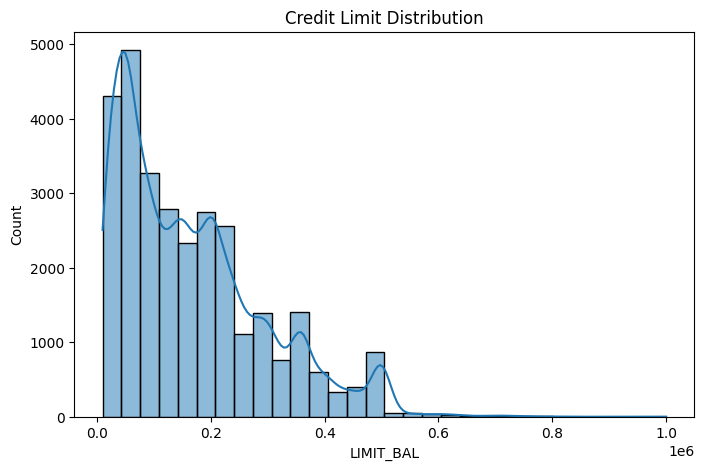

In [56]:
plt.figure(figsize=(8,5))

sns.histplot(
    df['LIMIT_BAL'],
    bins=30,
    kde=True
)

plt.title("Credit Limit Distribution")

plt.show()

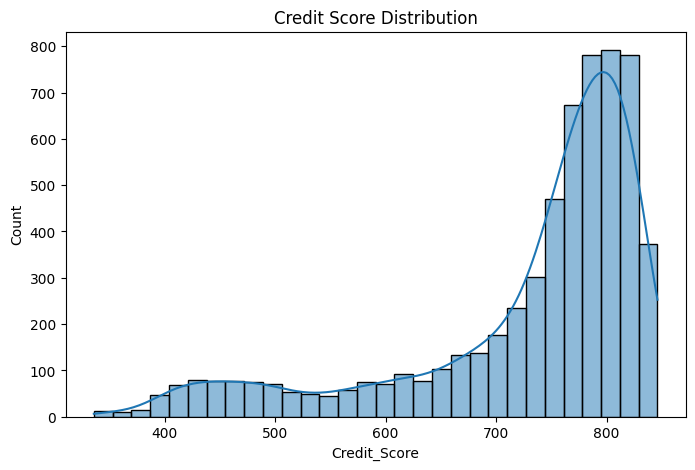

In [96]:
plt.figure(figsize=(8,5))

sns.histplot(
    score_df["Credit_Score"],
    bins=30,
    kde=True
)

plt.title("Credit Score Distribution")
plt.savefig("../reports/credit_score_distribution.png")
plt.show()

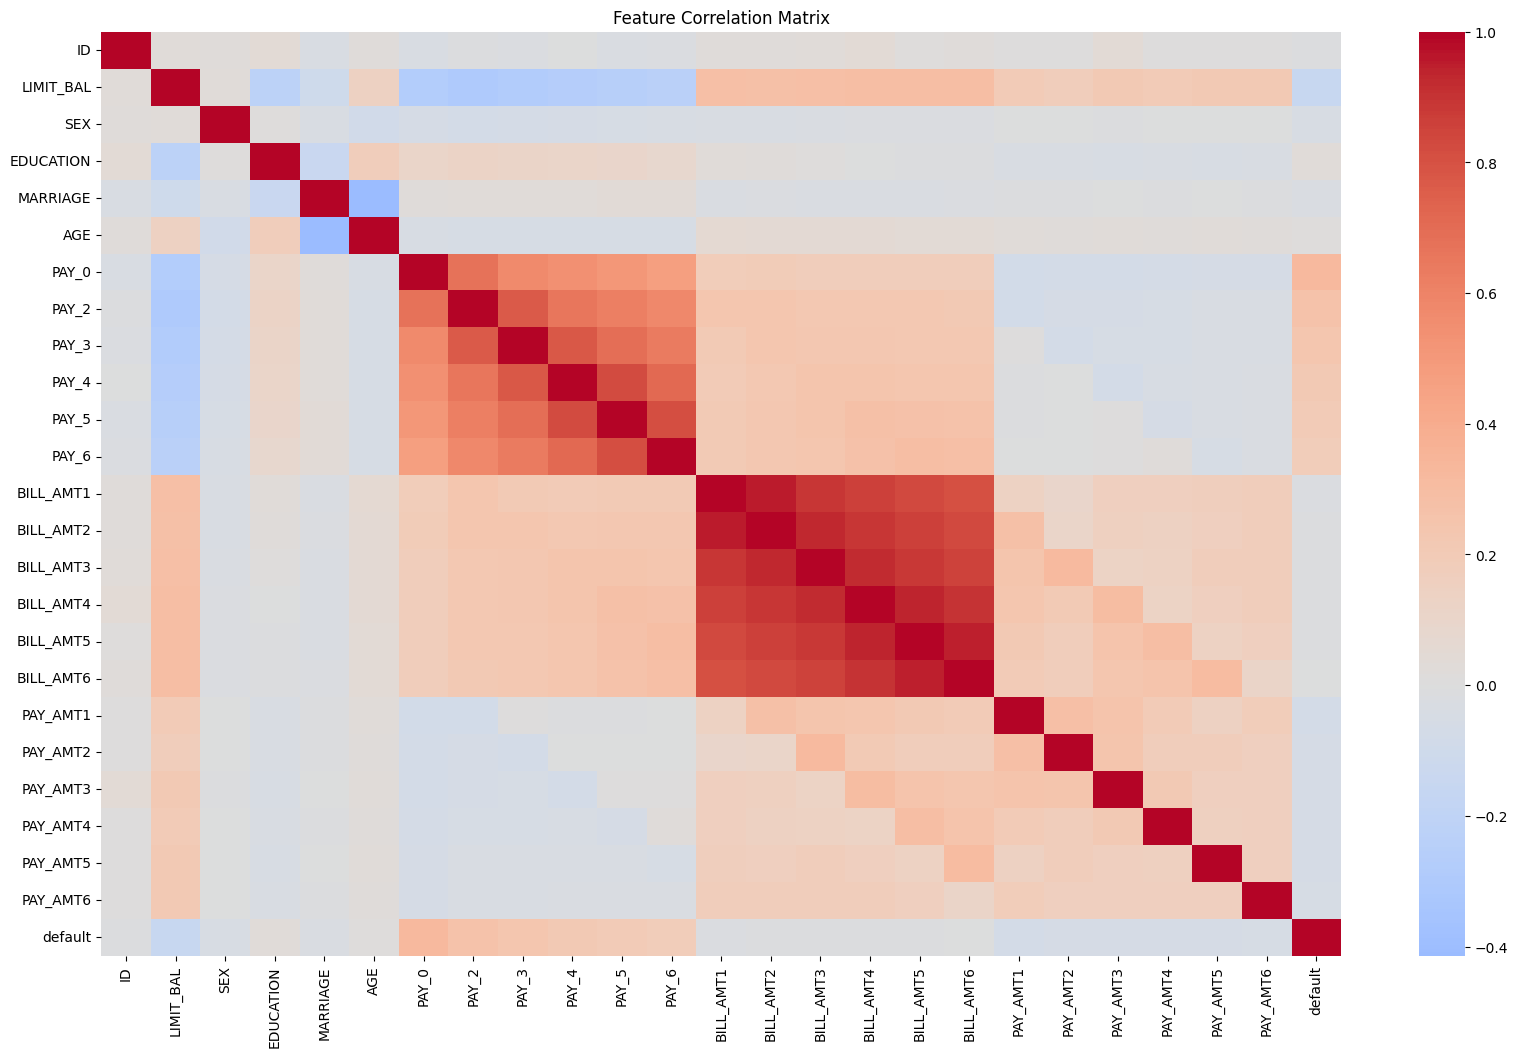

In [57]:
plt.figure(figsize=(20,12))

corr = df.corr()

sns.heatmap(
    corr,
    cmap='coolwarm',
    center=0
)

plt.title("Feature Correlation Matrix")

plt.show()

In [58]:
bill_cols = [
    'BILL_AMT1',
    'BILL_AMT2',
    'BILL_AMT3',
    'BILL_AMT4',
    'BILL_AMT5',
    'BILL_AMT6'
]
df['TOTAL_BILL'] = df[bill_cols].sum(axis=1)

In [59]:
payment_cols = [
    'PAY_AMT1',
    'PAY_AMT2',
    'PAY_AMT3',
    'PAY_AMT4',
    'PAY_AMT5',
    'PAY_AMT6'
]
df['TOTAL_PAYMENT'] = df[payment_cols].sum(axis=1)

In [60]:
df['PAYMENT_RATIO'] = (
    df['TOTAL_PAYMENT'] /
    (df['TOTAL_BILL'].abs() + 1)
)

In [61]:
df['CREDIT_AVAILABLE'] = (
    df['LIMIT_BAL'] -
    df['TOTAL_BILL']
)

In [62]:
df['UTILIZATION_RATIO'] = (
    df['TOTAL_BILL'] /
    (df['LIMIT_BAL'] + 1)
)

In [66]:
df['PAYMENT_DEFICIT'] = (
    df['TOTAL_BILL'] -
    df['TOTAL_PAYMENT']
)

In [67]:
pay_cols = [
    'PAY_0',
    'PAY_2',
    'PAY_3',
    'PAY_4',
    'PAY_5',
    'PAY_6'
]

df['AVG_DELAY'] = df[pay_cols].mean(axis=1)

In [69]:
df[[
    'TOTAL_BILL',
    'TOTAL_PAYMENT',
    'PAYMENT_RATIO',
    'CREDIT_AVAILABLE',
    'UTILIZATION_RATIO',
    'PAYMENT_DEFICIT',
    'AVG_DELAY'
]].head()

,TOTAL_BILL,TOTAL_PAYMENT,PAYMENT_RATIO,CREDIT_AVAILABLE,UTILIZATION_RATIO,PAYMENT_DEFICIT,AVG_DELAY
0,7704.0,689.0,0.089422,12296.0,0.385181,7015.0,-0.333333
1,17077.0,5000.0,0.292774,102923.0,0.142307,12077.0,0.500000
2,101653.0,11018.0,0.108387,-11653.0,1.129465,90635.0,0.000000
3,231334.0,8388.0,0.036259,-181334.0,4.626587,222946.0,0.000000
4,109339.0,59049.0,0.540049,-59339.0,2.186736,50290.0,-0.333333


In [20]:
df.drop('ID', axis=1, inplace=True)

In [21]:
from sklearn.model_selection import train_test_split

X = df.drop('default', axis=1)
y = df['default']

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print(X_train.shape)
print(X_test.shape)

(24000, 27)
(6000, 27)


In [70]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

from imblearn.over_sampling import SMOTE

smote = SMOTE(random_state=42)

X_train_smote, y_train_smote = smote.fit_resample(
    X_train_scaled,
    y_train
)

print("Before SMOTE")
print(y_train.value_counts())

print("\nAfter SMOTE")
print(y_train_smote.value_counts())

Before SMOTE
default
0    18691
1     5309
Name: count, dtype: int64

After SMOTE
default
0    18691
1    18691
Name: count, dtype: int64


In [71]:
lr = LogisticRegression(
    max_iter=1000,
    random_state=42
)

lr.fit(
    X_train_scaled,
    y_train
)

lr_preds = lr.predict(X_test_scaled)

lr_probs = lr.predict_proba(X_test_scaled)[:, 1]

In [72]:
lr_smote = LogisticRegression(
    max_iter=1000,
    random_state=42
)

lr_smote.fit(
    X_train_smote,
    y_train_smote
)

preds_smote = lr_smote.predict(
    X_test_scaled
)

lr_smote_probs = lr_smote.predict_proba(
    X_test_scaled
)[:,1]

lr_smote_auc = roc_auc_score(
    y_test,
    lr_smote_probs
)

print("Logistic Regression + SMOTE")
print("-" * 50)

print(
    classification_report(
        y_test,
        preds_smote
    )
)

print("ROC-AUC:", lr_smote_auc)

Logistic Regression + SMOTE
--------------------------------------------------
              precision    recall  f1-score   support

           0       0.87      0.70      0.77      4673
           1       0.37      0.62      0.46      1327

    accuracy                           0.68      6000
   macro avg       0.62      0.66      0.62      6000
weighted avg       0.76      0.68      0.70      6000

ROC-AUC: 0.7116791599386622


In [73]:
rf = RandomForestClassifier(
    n_estimators=300,
    max_depth=10,
    random_state=42,
    class_weight='balanced'
)

rf.fit(
    X_train,
    y_train
)

rf_preds = rf.predict(X_test)

rf_probs = rf.predict_proba(X_test)[:,1]

rf_auc = roc_auc_score(
    y_test,
    rf_probs
)

print("Random Forest")
print("-" * 50)

print(
    classification_report(
        y_test,
        rf_preds
    )
)

print("ROC-AUC:", rf_auc)

Random Forest
--------------------------------------------------
              precision    recall  f1-score   support

           0       0.88      0.83      0.85      4673
           1       0.49      0.59      0.54      1327

    accuracy                           0.78      6000
   macro avg       0.69      0.71      0.69      6000
weighted avg       0.79      0.78      0.78      6000

ROC-AUC: 0.7777561327712583


In [74]:
xgb = XGBClassifier(
    n_estimators=300,
    max_depth=5,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    eval_metric='logloss'
)

xgb.fit(
    X_train,
    y_train
)

xgb_preds = xgb.predict(X_test)

xgb_probs = xgb.predict_proba(
    X_test
)[:,1]

xgb_auc = roc_auc_score(
    y_test,
    xgb_probs
)

print("XGBoost")
print("-" * 50)

print(
    classification_report(
        y_test,
        xgb_preds
    )
)

print("ROC-AUC:", xgb_auc)

XGBoost
--------------------------------------------------
              precision    recall  f1-score   support

           0       0.84      0.95      0.89      4673
           1       0.66      0.37      0.47      1327

    accuracy                           0.82      6000
   macro avg       0.75      0.66      0.68      6000
weighted avg       0.80      0.82      0.80      6000

ROC-AUC: 0.7788833574071318


In [75]:
print("Baseline Logistic Regression")
print("-" * 50)

print(
    classification_report(
        y_test,
        lr_preds
    )
)

lr_probs = lr.predict_proba(
    X_test_scaled
)[:,1]

lr_auc = roc_auc_score(
    y_test,
    lr_probs
)

print("ROC AUC:", lr_auc)

Baseline Logistic Regression
--------------------------------------------------
              precision    recall  f1-score   support

           0       0.82      0.97      0.89      4673
           1       0.70      0.24      0.36      1327

    accuracy                           0.81      6000
   macro avg       0.76      0.61      0.63      6000
weighted avg       0.79      0.81      0.77      6000

ROC AUC: 0.70843584922669


In [76]:
results = pd.DataFrame({
    "Model":[
        "Logistic Regression",
        "Logistic Regression + SMOTE",
        "Random Forest",
        "XGBoost"
    ],
    "ROC_AUC":[
        round(lr_auc,4),
        round(lr_smote_auc,4),
        round(rf_auc,4),
        round(xgb_auc,4)
    ]
})

results = results.sort_values(
    by="ROC_AUC",
    ascending=False
)

results

,Model,ROC_AUC
3,XGBoost,0.7789
2,Random Forest,0.7778
1,Logistic Regression + SMOTE,0.7117
0,Logistic Regression,0.7084


In [77]:
feature_importance = pd.DataFrame({
    'Feature': X_train.columns,
    'Importance': xgb.feature_importances_
})

feature_importance = feature_importance.sort_values(
    by='Importance',
    ascending=False
)

feature_importance.head(15)

,Feature,Importance
5,PAY_0,0.381329
26,AVG_DELAY,0.085352
6,PAY_2,0.083069
7,PAY_3,0.037143
8,PAY_4,0.028393
24,TOTAL_PAYMENT,0.023978
9,PAY_5,0.022068
25,UTILIZATION_RATIO,0.020404
0,LIMIT_BAL,0.019800
19,PAY_AMT3,0.019578


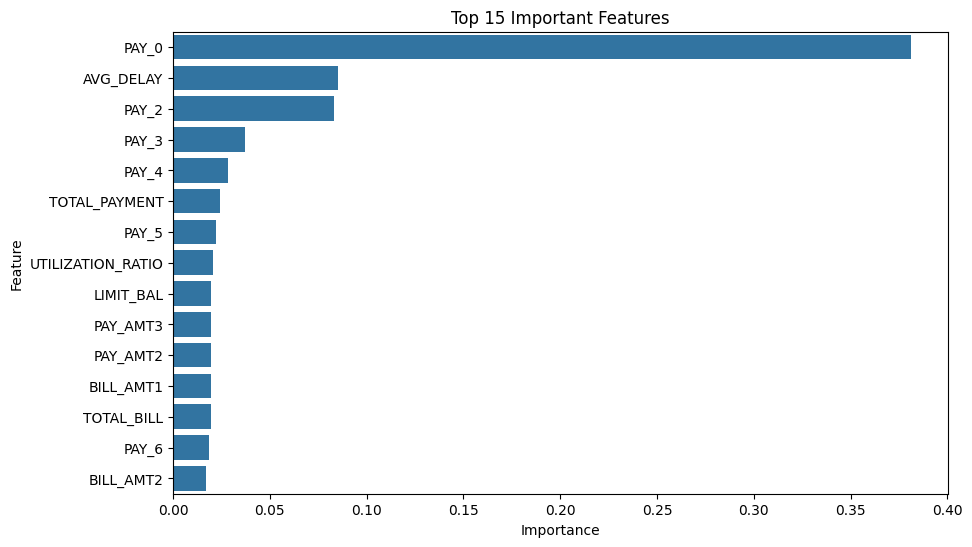

In [93]:
plt.figure(figsize=(10,6))

sns.barplot(
    data=feature_importance.head(15),
    x='Importance',
    y='Feature'
)
plt.savefig("../reports/feature_importance.png")
plt.title("Top 15 Important Features")
plt.show()

In [79]:
xgb_probs = xgb.predict_proba(X_test)[:,1]

In [80]:
credit_scores = 850 - (xgb_probs * 550)

In [81]:
score_df = pd.DataFrame({
    "Default_Probability": xgb_probs,
    "Credit_Score": credit_scores.astype(int)
})

score_df.head()

,Default_Probability,Credit_Score
0,0.238347,718
1,0.177181,752
2,0.195858,742
3,0.145313,770
4,0.017669,840


In [87]:
def assign_risk(score):
    if score >= 800:
        return "Very Low Risk"
    elif score >= 700:
        return "Low Risk"
    elif score >= 600:
        return "Medium Risk"
    else:
        return "High Risk"

score_df["Risk_Category"] = score_df[
    "Credit_Score"
].apply(assign_risk)

score_df.head()

,Default_Probability,Credit_Score,Risk_Category
0,0.238347,718,Low Risk
1,0.177181,752,Low Risk
2,0.195858,742,Low Risk
3,0.145313,770,Low Risk
4,0.017669,840,Very Low Risk


In [88]:
score_df["Risk_Category"].value_counts()

Risk_Category
Low Risk         2803
Very Low Risk    1706
High Risk         841
Medium Risk       650
Name: count, dtype: int64

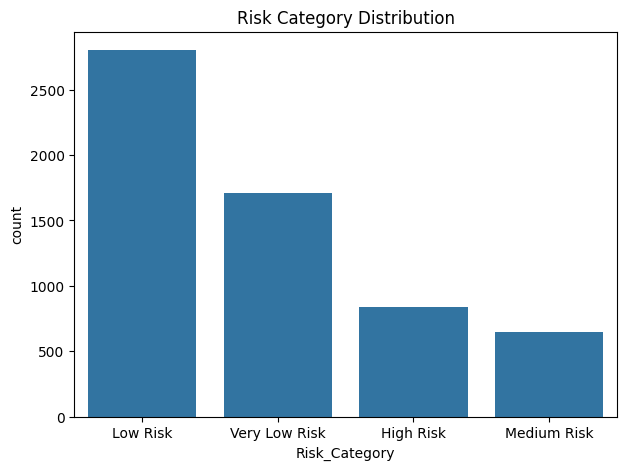

In [89]:
plt.figure(figsize=(7,5))

sns.countplot(
    x="Risk_Category",
    data=score_df
)

plt.title("Risk Category Distribution")
plt.show()

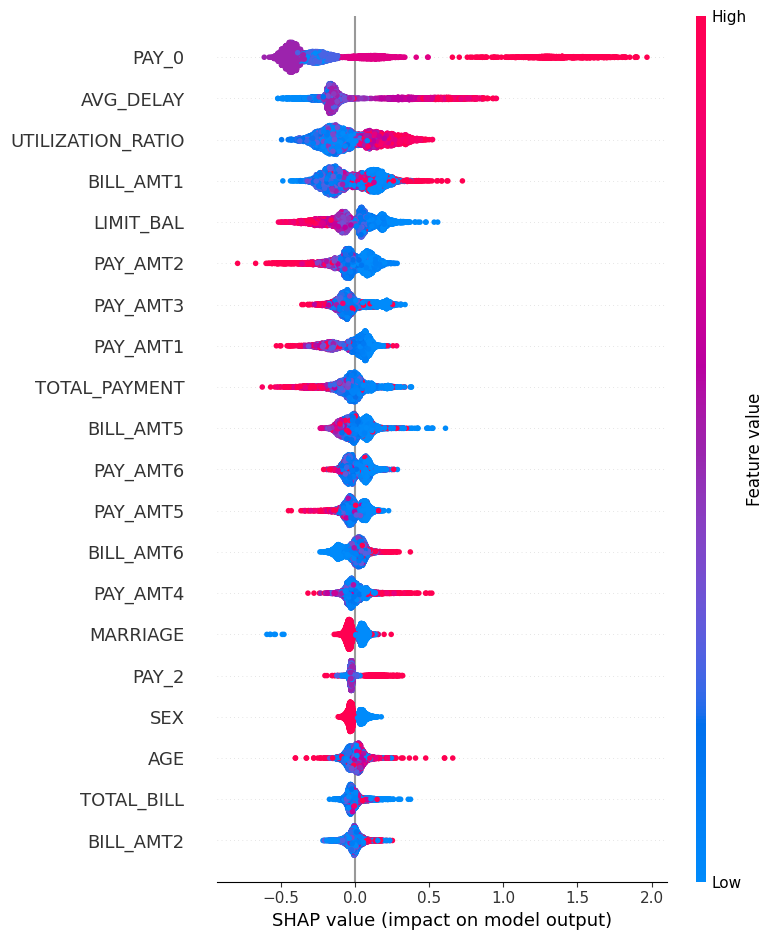

<Figure size 640x480 with 0 Axes>

In [98]:
import shap

explainer = shap.TreeExplainer(xgb)

shap_values = explainer.shap_values(X_test)

shap.summary_plot(
    shap_values,
    X_test
)
plt.tight_layout()
plt.savefig(
    "../reports/shap_summary.png",
    dpi=300,
    bbox_inches="tight"
)
plt.show()

In [85]:
import joblib

joblib.dump(
    xgb,
    "../models/credit_risk_model.pkl"
)

joblib.dump(
    scaler,
    "../models/scaler.pkl"
)

['../models/scaler.pkl']